In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.animation as animation
import matplotlib.cm as cm
from matplotlib.patches import Rectangle
from tqdm import tqdm
from PIL import Image
import os
import gc
import warnings
from funcs import *
import cupy as cp

def _to_numpy(array):
    """Convert a NumPy/CuPy-compatible array to a NumPy array for plotting."""
    return cp.asnumpy(array) if isinstance(array, cp.ndarray) else np.asarray(array)

%matplotlib inline
warnings.filterwarnings('ignore')

# Shared court grid used by bin_and_flip and the synthetic effect maps.
x_bins = 20
y_bins = 10

# Synthetic Threat-Profile Construction

This notebook is a recovery experiment: it defines a known spatial scoring pattern, generates synthetic possession outcomes from that pattern, and then asks the total-variation (TV) logistic/QUT pipeline to reconstruct the pattern from the simulated data.

## End-to-end workflow

1. Load cleaned, half-court-filtered ball-tracking observations.
2. Discretize court coordinates into a shared `20 × 10` grid. These calls use `flip="yes"`, which bypasses the optional rotation block in the current `bin_and_flip` implementation. A sector is represented by `(x_bin, y_bin)`.
3. Sample complete possessions from six training games and summarize which sectors each possession visited.
4. Apply manually specified movement and end-location effects to a baseline scoring probability.
5. Draw one Bernoulli outcome per possession using the resulting probability.
6. Replace the observed scoring label with the simulated label and retain only the four columns required by QUT.
7. Run `analyze_tv_logistic_single_game` on the simulated data and compare its estimated spatial profile with the known input profile.

The training games are `21500649`, `21500390`, `21500188`, `21500355`, `21500057`, and `21500009`. All simulations use the same games and model settings but different spatial effects and random seeds.

## Important conventions

- Effect arrays have shape `(x_bins, y_bins)` and are indexed as `effects[x_bin, y_bin]`.
- Plotting uses `effect.T` because image rows correspond to the vertical/y axis.
- Effects are **additive changes to probability**, not log-odds: `p = clip(baseline + movement + end, 0, 1)`.
- Movement effects are summed over the sectors represented in the possession summary. If a weight column is supplied, each sector effect is multiplied by that weight first.
- End effects contribute only for the possession's final sector.
- The profile cells reuse the same `pipeline_*` names. Save or rename a result before running the next profile if side-by-side comparison is required.

## 1. Load and bin the tracking data

The input CSV must contain the identifiers and coordinates used by `bin_and_flip`, including `game_id`, `possession_number`, `period`, `is_home`, `x`, `y`, and `scored`. Each row is a tracking sample, so a possession normally appears in many rows.

`bin_and_flip` converts continuous coordinates to integer `x_bin` and `y_bin` values. In the current helper implementation, `flip="no"` performs the home/away, half, and game-level rotations, whereas `flip="yes"` skips those rotations. This notebook uses `"yes"` because the prepared input is already supplied in the desired orientation. The `sector` tuple is then the stable key used by the simulation helpers. The displayed frames below are inspection checkpoints; they do not mutate the data.

In [2]:
# One row represents one tracking observation within a possession.
cleaned = pd.read_csv("multi_game_data/multi_game_data_half_court_filtered.csv")

In [3]:
cleaned

,game_id,home_away,is_home,period,time,x,y,z,source_possession_start,source_possession_end,possession_start,possession_end,ORIGINAL_POSSESSION_NUMBER,SOURCE_POSSESSION_NUMBER,possession_number,source_points_scored,points_scored,scored,contains_confirmed_continuation,half_court_crossings
0,21500009,home,1,1,719.00,37.04728,15.02163,6.44393,720,703,720,703,1,1,1,2,2,1,False,1
1,21500009,home,1,1,718.96,36.30142,14.70948,6.12091,720,703,720,703,1,1,1,2,2,1,False,1
2,21500009,home,1,1,718.92,35.67854,14.33637,5.70189,720,703,720,703,1,1,1,2,2,1,False,1
3,21500009,home,1,1,718.88,34.84530,13.68251,5.15255,720,703,720,703,1,1,1,2,2,1,False,1
4,21500009,home,1,1,718.84,34.18749,13.55080,4.64143,720,703,720,703,1,1,1,2,2,1,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283967,21500649,home,1,4,21.13,89.05357,25.22764,7.01554,34,21,34,21,175,86,84,2,2,1,False,1
283968,21500649,home,1,4,21.09,88.85823,25.43094,6.69550,34,21,34,21,175,86,84,2,2,1,False,1
283969,21500649,home,1,4,21.05,89.01390,25.20261,5.98559,34,21,34,21,175,86,84,2,2,1,False,1
283970,21500649,home,1,4,21.01,89.04044,25.37756,6.20067,34,21,34,21,175,86,84,2,2,1,False,1


In [4]:
# The prepared data already has the desired orientation; flip="yes" skips
# reorientation and discretizes the coordinates on the shared grid.
cleaned_binned = bin_and_flip(cleaned, flip="yes", x_bins=x_bins, y_bins=y_bins)
# Tuple keys make sector-level grouping and effect lookup explicit.
cleaned_binned["sector"] = list(zip(cleaned_binned["x_bin"], cleaned_binned["y_bin"]))
cleaned_binned

,game_id,home_away,is_home,period,time,x,y,z,source_possession_start,source_possession_end,...,SOURCE_POSSESSION_NUMBER,possession_number,source_points_scored,points_scored,scored,contains_confirmed_continuation,half_court_crossings,x_bin,y_bin,sector
0,21500009,home,1,1,719.00,37.04728,15.02163,6.44393,720,703,...,1,1,2,2,1,False,1,7,3,"(7, 3)"
1,21500009,home,1,1,718.96,36.30142,14.70948,6.12091,720,703,...,1,1,2,2,1,False,1,7,2,"(7, 2)"
2,21500009,home,1,1,718.92,35.67854,14.33637,5.70189,720,703,...,1,1,2,2,1,False,1,7,2,"(7, 2)"
3,21500009,home,1,1,718.88,34.84530,13.68251,5.15255,720,703,...,1,1,2,2,1,False,1,7,2,"(7, 2)"
4,21500009,home,1,1,718.84,34.18749,13.55080,4.64143,720,703,...,1,1,2,2,1,False,1,7,2,"(7, 2)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283967,21500649,home,1,4,21.13,89.05357,25.22764,7.01554,34,21,...,86,84,2,2,1,False,1,18,5,"(18, 5)"
283968,21500649,home,1,4,21.09,88.85823,25.43094,6.69550,34,21,...,86,84,2,2,1,False,1,18,5,"(18, 5)"
283969,21500649,home,1,4,21.05,89.01390,25.20261,5.98559,34,21,...,86,84,2,2,1,False,1,18,5,"(18, 5)"
283970,21500649,home,1,4,21.01,89.04044,25.37756,6.20067,34,21,...,86,84,2,2,1,False,1,18,5,"(18, 5)"


## 2. Possession summarization and simulation helpers

The helpers below form the reusable simulation layer:

- `build_visited_possessions` reduces tracking rows to one row per possession-sector pair and attaches visit duration/proportion, the possession outcome, the final-sector flag, and a recent-visit flag.
- `_sector_effect_lookup` safely reads an effect from either a dictionary or a NumPy/CuPy matrix. Out-of-grid sectors receive zero effect.
- `create_baseline_scoring_probabilities` aggregates sector effects to one scoring probability per possession.
- `plot_effect_surfaces` visualizes movement and end effects over the court image with one grid unit per bin.
- `sample_possessions_from_games` samples possession identifiers—not individual tracking rows—so each selected possession remains intact.
- `build_baseline_scoring_pipeline` composes sampling, binning, possession summarization, and probability construction, returning intermediate tables for inspection.

The misspelled key `visited_posssessions` is retained for compatibility with the existing profile cells.

In [5]:
possession_cols = ["game_id", "possession_number"]


def build_visited_possessions(
    binned_df,
    possession_cols=possession_cols,
    sector_col="sector",
    scored_col="scored",
    sample_interval_seconds=0.04,
    last_n_unique_visited=5,
):
    """Summarize tracking observations at the possession-sector level.

    Parameters
    ----------
    binned_df : pandas.DataFrame
        Tracking rows with possession identifiers, a sector tuple, and a
        possession-level scoring label repeated across the tracking rows.
    possession_cols : sequence of str
        Columns that jointly identify a possession.
    sector_col : str
        Column containing `(x_bin, y_bin)` tuples.
    scored_col : str
        Binary possession outcome. `max` is used to collapse repeated values.
    sample_interval_seconds : float
        Seconds represented by one tracking row; used to convert visit counts
        into approximate time spent in each sector.
    last_n_unique_visited : int
        Number of most recently visited distinct sectors to flag.

    Returns
    -------
    pandas.DataFrame
        One row per possession-sector pair. Besides identifiers and `count`,
        the result contains `time`, `time_proportion`, the scoring outcome,
        `is_end_sector`, and `was_last_<N>_visited`.

    Notes
    -----
    The end sector is taken from the last tracking row of each possession.
    Recent sectors are ordered by their last occurrence in the raw rows.
    """
    required_cols = set(possession_cols) | {sector_col, scored_col}
    missing_cols = required_cols.difference(binned_df.columns)
    if missing_cols:
        raise ValueError(f"binned_df is missing required columns: {sorted(missing_cols)}")

    visited = binned_df.groupby(possession_cols, observed=False)[sector_col].value_counts().reset_index()
    visited["time"] = visited["count"] * sample_interval_seconds
    visited["time_proportion"] = (
        visited["count"]
        / visited.groupby(possession_cols, observed=False)["count"].transform("sum")
    )

    possession_scoring = (
        binned_df.groupby(possession_cols, observed=False)[scored_col].max().reset_index()
    )
    visited = visited.merge(possession_scoring, on=possession_cols, how="left")

    end_sector = (
        binned_df.drop_duplicates(possession_cols, keep="last")
        .assign(is_end_sector=True)[possession_cols + [sector_col, "is_end_sector"]]
    )
    visited = visited.merge(end_sector, on=possession_cols + [sector_col], how="left")
    visited["is_end_sector"] = visited["is_end_sector"].eq(True)

    last_visited_col = f"was_last_{last_n_unique_visited}_visited"
    last_visited = (
        binned_df.drop_duplicates(possession_cols + [sector_col], keep="last")
        .groupby(possession_cols, observed=False)
        .tail(last_n_unique_visited)
        .assign(**{last_visited_col: True})[possession_cols + [sector_col, last_visited_col]]
    )
    visited = visited.merge(last_visited, on=possession_cols + [sector_col], how="left")
    visited[last_visited_col] = visited[last_visited_col].eq(True)

    return visited


def _sector_effect_lookup(sector, effects):
    """Return the effect assigned to one `(x_bin, y_bin)` sector.

    `effects` may be `None`, a dictionary keyed by sector tuples, or a 2-D
    NumPy/CuPy array indexed as `[x_bin, y_bin]`. Missing dictionary keys and
    coordinates outside the matrix bounds deliberately contribute `0.0`.
    CuPy scalars are copied back to the host and returned as Python floats.
    """
    if effects is None:
        return 0.0

    if isinstance(effects, dict):
        return effects.get(sector, 0.0)

    x_bin, y_bin = sector
    if 0 <= x_bin < effects.shape[0] and 0 <= y_bin < effects.shape[1]:
        if isinstance(effects, cp.ndarray):
            return float(effects[x_bin, y_bin].get())
        return effects[x_bin, y_bin]

    return 0.0


def create_baseline_scoring_probabilities(
    visited_possessions,
    movement_effects=None,
    end_effects=None,
    baseline_probability=None,
    possession_cols=("game_id", "possession_number"),
    sector_col="sector",
    movement_weight_col=None,
    end_indicator_col="is_end_sector",
    scored_col="scored",
):
    """Construct one additive scoring probability per possession.

    Parameters
    ----------
    visited_possessions : pandas.DataFrame
        Output of `build_visited_possessions` or an equivalent table with one
        row per possession-sector pair.
    movement_effects, end_effects : dict or array-like, optional
        Sector-level probability adjustments. Arrays must use shape
        `(x_bins, y_bins)` and `[x_bin, y_bin]` indexing.
    baseline_probability : float, optional
        Starting probability shared by all possessions. When omitted, it is
        estimated as the observed mean outcome across possessions.
    possession_cols : sequence of str
        Columns that jointly identify a possession.
    sector_col : str
        Column containing sector tuple keys.
    movement_weight_col : str, optional
        If provided, multiply each movement effect by this column before
        summing. Useful choices include `time` or `time_proportion`.
    end_indicator_col : str
        Boolean flag selecting the single final sector of a possession.
    scored_col : str
        Observed outcome column, retained in the returned diagnostic table.

    Returns
    -------
    pandas.DataFrame
        One row per possession with baseline, movement, and end components;
        the unclipped total; the final probability clipped to `[0, 1]`; and,
        when available, the observed scoring label.

    Notes
    -----
    This is an additive probability model, not a logistic transformation:
    `p = clip(p0 + sum(movement effects) + final-sector effect, 0, 1)`.
    With no `movement_weight_col`, a sector contributes once because the input
    table has already been collapsed to unique possession-sector pairs.
    """
    required_cols = set(possession_cols) | {sector_col}
    if movement_weight_col is not None:
        required_cols.add(movement_weight_col)
    missing_cols = required_cols.difference(visited_possessions.columns)
    if missing_cols:
        raise ValueError(f"visited_possessions is missing required columns: {sorted(missing_cols)}")

    df = visited_possessions.copy()

    if baseline_probability is None:
        if scored_col not in df.columns:
            raise ValueError("Provide baseline_probability or include a scored column.")
        baseline_probability = df.groupby(list(possession_cols), observed=False)[scored_col].max().mean()

    baseline_probability = np.clip(baseline_probability, 0, 1)
    df["movement_sector_effect"] = df[sector_col].apply(
        lambda sector: _sector_effect_lookup(sector, movement_effects)
    )
    if movement_weight_col is None:
        df["movement_probability_adjustment"] = df["movement_sector_effect"]
    else:
        df["movement_probability_adjustment"] = df["movement_sector_effect"] * df[movement_weight_col]

    if end_indicator_col in df.columns:
        df["end_sector_effect"] = df[sector_col].apply(
            lambda sector: _sector_effect_lookup(sector, end_effects)
        )
        df["end_probability_adjustment"] = np.where(df[end_indicator_col], df["end_sector_effect"], 0.0)
    else:
        df["end_probability_adjustment"] = 0.0

    probability_components = (
        df.groupby(list(possession_cols), observed=False)
        .agg(
            movement_probability_adjustment=("movement_probability_adjustment", "sum"),
            end_probability_adjustment=("end_probability_adjustment", "sum"),
        )
        .reset_index()
    )

    probability_components["movement_probability_adjustment"] = (
        probability_components["movement_probability_adjustment"].round(10)
    )
    probability_components["baseline_probability"] = baseline_probability
    probability_components["raw_scoring_probability"] = (
        probability_components["baseline_probability"]
        + probability_components["movement_probability_adjustment"]
        + probability_components["end_probability_adjustment"]
    )
    probability_components["scoring_probability"] = probability_components["raw_scoring_probability"].clip(0, 1)

    if scored_col in df.columns:
        actual_scoring = df.groupby(list(possession_cols), observed=False)[scored_col].max().reset_index()
        probability_components = probability_components.merge(actual_scoring, on=list(possession_cols), how="left")

    return probability_components


def plot_effect_surfaces(
    movement_effects,
    end_effects,
    court_image_path="court.jpg",
    x_bins=x_bins,
    y_bins=y_bins,
    title_prefix="Pipeline",
):
    """Plot movement and final-sector effect matrices over a court image.

    Both inputs must describe the same `(x_bins, y_bins)` grid. The matrices
    are transposed for display so x runs horizontally and y vertically. A
    shared symmetric color scale is used, making positive and negative effects
    directly comparable across the two panels. Set `court_image_path=None` to
    plot the effect grids without a background image.

    Returns
    -------
    None
        Displays a Matplotlib figure as a side effect.
    """
    effect_maps = [_to_numpy(movement_effects), _to_numpy(end_effects)]
    titles = [f"{title_prefix} Movement Effects", f"{title_prefix} End Effects"]
    v_abs = max(float(np.nanmax(np.abs(effect))) for effect in effect_maps)
    v_abs = v_abs if v_abs > 0 else 1.0

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
    court = Image.open(court_image_path) if court_image_path is not None else None

    for ax, effect, title in zip(axes, effect_maps, titles):
        if court is not None:
            ax.imshow(court, extent=[0, x_bins, 0, y_bins], aspect="auto")

        im = ax.imshow(
            effect.T,
            origin="lower",
            extent=[0, x_bins, 0, y_bins],
            cmap="coolwarm",
            alpha=0.75,
            vmin=-v_abs,
            vmax=v_abs,
        )

        for x in range(x_bins + 1):
            ax.axvline(x, color="white", lw=0.5, alpha=0.35)
        for y in range(y_bins + 1):
            ax.axhline(y, color="white", lw=0.5, alpha=0.35)

        ax.set_xlim(0, x_bins)
        ax.set_ylim(0, y_bins)
        ax.set_title(title)
        ax.set_xlabel("x_bin")
        ax.set_ylabel("y_bin")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Probability Adjustment")

    plt.show()


def sample_possessions_from_games(
    df,
    game_ids,
    n_possessions,
    possession_cols=possession_cols,
    random_state=None,
    reindex_possessions=True,
):
    """Sample complete possessions from a selected collection of games.

    Sampling is performed on unique possession keys and then joined back to all
    tracking rows. Sampling switches to replacement only when `n_possessions`
    exceeds the number of available possession keys. When reindexing is on,
    sampled possessions receive identifiers `0..n_possessions-1`, while the
    source identifier is retained in `original_possession_number`. This also
    keeps repeated draws distinct when sampling with replacement.

    Returns
    -------
    pandas.DataFrame
        All tracking rows belonging to the sampled possession draws.
    """
    game_col, possession_col = possession_cols
    game_df = df[df[game_col].isin(game_ids)].copy()
    possession_keys = game_df[possession_cols].drop_duplicates()

    if possession_keys.empty:
        raise ValueError("No possessions found for the requested game_ids.")

    replace = n_possessions > len(possession_keys)
    sampled_keys = possession_keys.sample(
        n=n_possessions,
        replace=replace,
        random_state=random_state,
    ).reset_index(drop=True)

    if reindex_possessions:
        sampled_keys = sampled_keys.assign(_sample_possession_number=lambda x: x.index)
        sampled = sampled_keys.merge(game_df, on=possession_cols, how="left")
        sampled["original_possession_number"] = sampled[possession_col]
        sampled[possession_col] = sampled["_sample_possession_number"]
        return sampled.drop(columns="_sample_possession_number")

    return game_df.merge(sampled_keys, on=possession_cols, how="inner")


def build_baseline_scoring_pipeline(
    df,
    train_games,
    n_possessions,
    movement_effects=None,
    end_effects=None,
    baseline_probability=0.50,
    random_state=None,
    flip="yes",
    movement_weight_col=None,
    reindex_possessions=True,
):
    """Run the preprocessing portion of the synthetic-outcome pipeline.

    The function samples complete possessions, bins (and optionally reorients)
    their tracking coordinates with `bin_and_flip`, builds `(x_bin, y_bin)`
    sector keys,
    summarizes sector visits, and calculates one scoring probability per
    sampled possession. It does not draw Bernoulli outcomes or run QUT; those
    steps remain explicit in each profile cell below.

    Parameters
    ----------
    df : pandas.DataFrame
        Cleaned tracking observations.
    train_games : iterable
        Game IDs eligible for possession sampling.
    n_possessions : int
        Number of complete possession draws.
    movement_effects, end_effects : dict or array-like, optional
        Spatial probability adjustments passed to
        `create_baseline_scoring_probabilities`.
    baseline_probability : float
        Probability before spatial adjustments.
    random_state : int, optional
        Seed used by pandas possession sampling.
    flip : {"yes", "no"}
        Option forwarded to `bin_and_flip`. In its current implementation,
        `"no"` applies orientation rotations and `"yes"` bypasses them.
    movement_weight_col : str, optional
        Optional sector weight, such as `time_proportion`.
    reindex_possessions : bool
        Whether to assign a unique sequential identifier to every sample draw.

    Returns
    -------
    dict
        Intermediate data frames: raw sampled rows, binned rows/QUT input,
        possession-sector summaries, and possession-level probabilities.
    """
    sampled_movement = sample_possessions_from_games(
        df,
        game_ids=train_games,
        n_possessions=n_possessions,
        random_state=random_state,
        reindex_possessions=reindex_possessions,
    )
    sampled_binned_movement = bin_and_flip(sampled_movement, flip=flip)
    sampled_binned_movement["sector"] = list(
        zip(sampled_binned_movement["x_bin"], sampled_binned_movement["y_bin"])
    )

    sampled_visited_posssessions = build_visited_possessions(sampled_binned_movement)
    sampled_baseline_scoring_probabilities = create_baseline_scoring_probabilities(
        sampled_visited_posssessions,
        movement_effects=movement_effects,
        end_effects=end_effects,
        baseline_probability=baseline_probability,
        movement_weight_col=movement_weight_col,
    )

    return {
        "sampled_movement": sampled_movement,
        "sampled_binned_movement": sampled_binned_movement,
        "qut_movement": sampled_binned_movement,
        "visited_posssessions": sampled_visited_posssessions,
        "baseline_scoring_probabilities": sampled_baseline_scoring_probabilities,
    }


## 3. Synthetic profile experiments

Each cell below follows the same experiment template:

1. Initialize zero-valued movement and end-effect matrices.
2. Assign positive or negative probability adjustments to selected matrix slices.
3. Plot the known input profile.
4. Sample 500 real movement trajectories and calculate their synthetic scoring probabilities from a baseline of `0.30`.
5. Use a seeded NumPy generator to draw one binary `simulated_out` per possession.
6. Merge that outcome onto every tracking row, expose the synthetic label as `scored`, and retain only the four columns required by QUT.
7. Stream 100 bootstrap datasets one at a time, obtain a QUT penalty from 100 Monte Carlo null draws, and estimate/plot TV-regularized percentile maps at `alpha = 0.05`.

`game_id=None` tells the analysis function to pool the sampled rows instead of filtering to one source game. `n_possessions=10000` and `samples_per_possession=50` are bootstrap-construction settings inside `analyze_tv_logistic_single_game`; they are distinct from the 500 possession trajectories initially sampled by the simulation pipeline.

### Profile interpretations

- **Seed 42 — reference court pattern:** combines favorable edge/deep-court regions, a strong terminal region, and unfavorable interior bands.
- **Seed 43 — high-y-side emphasis:** assigns positive effects to `y_bin` 6–9 across the offensive half.
- **Seed 44 — low-y-side emphasis:** assigns positive effects to `y_bin` 0–3 across the offensive half.
- **Seed 45 — perimeter-like pattern:** builds a stepped positive boundary with a negative interior strip.

The first profile runs immediately. The remaining profiles display their input surface and then request confirmation before starting the expensive bootstrap/QUT analysis.

In [7]:
# Reload the source so this experiment can be run independently of the preview cells.
pipeline_input_df = pd.read_csv("multi_game_data/multi_game_data_half_court_filtered.csv")

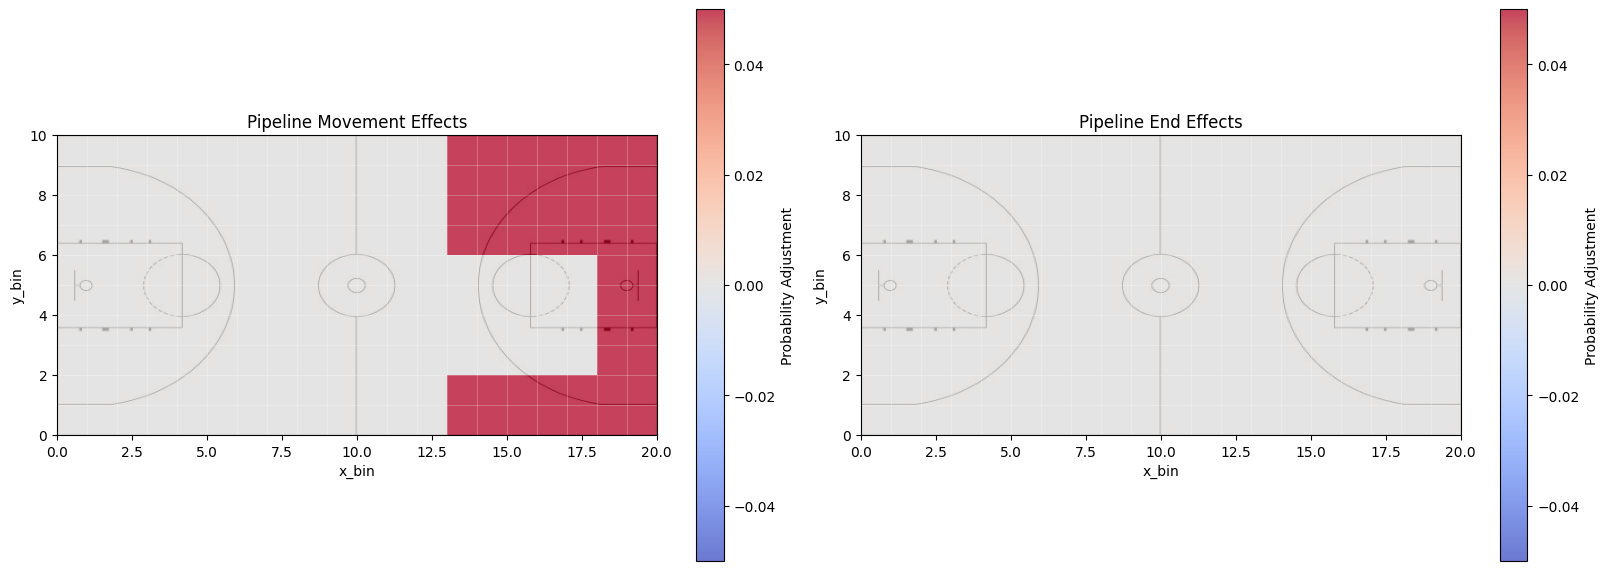


=== Processing single ===


Simulating null responses...
Accepted 100 / 100 simulations
λ_qut (95th percentile null): 82.3397
λ_max (data): 1717.7625


Processing Bootstrap Datasets: 100%|██████████| 100/100 [05:41<00:00,  3.41s/it]

λ_qut (95th percentile null): 82.3397
λ_max (observed): 1717.7625
95% CI for λ_max (bootstrap): [1597.7736, 1729.7692]
Empirical p-value (λ_max > λ_qut): 0.0000


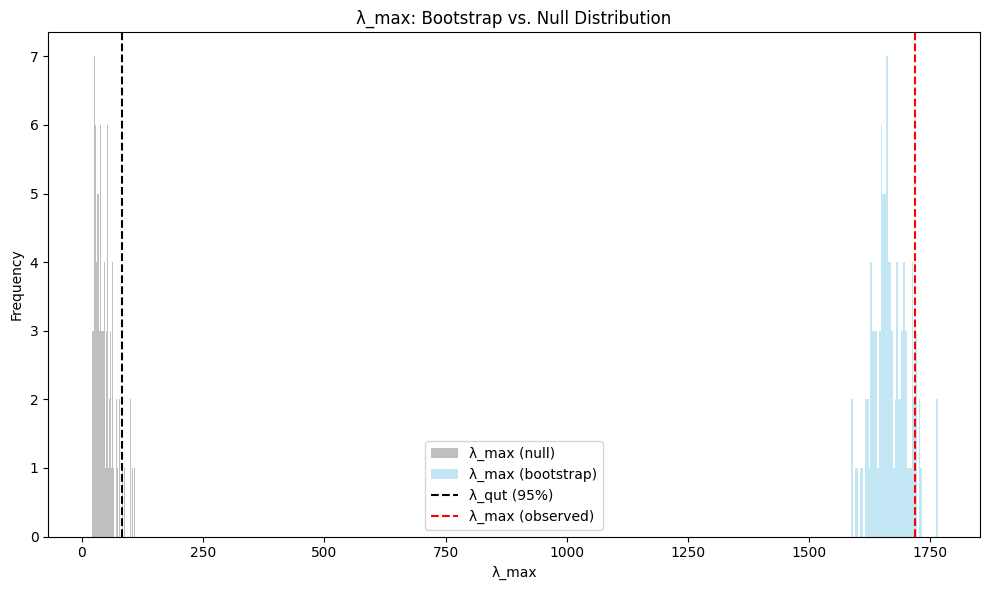

Plotting pointwise percentile maps at lambda = 82.3397


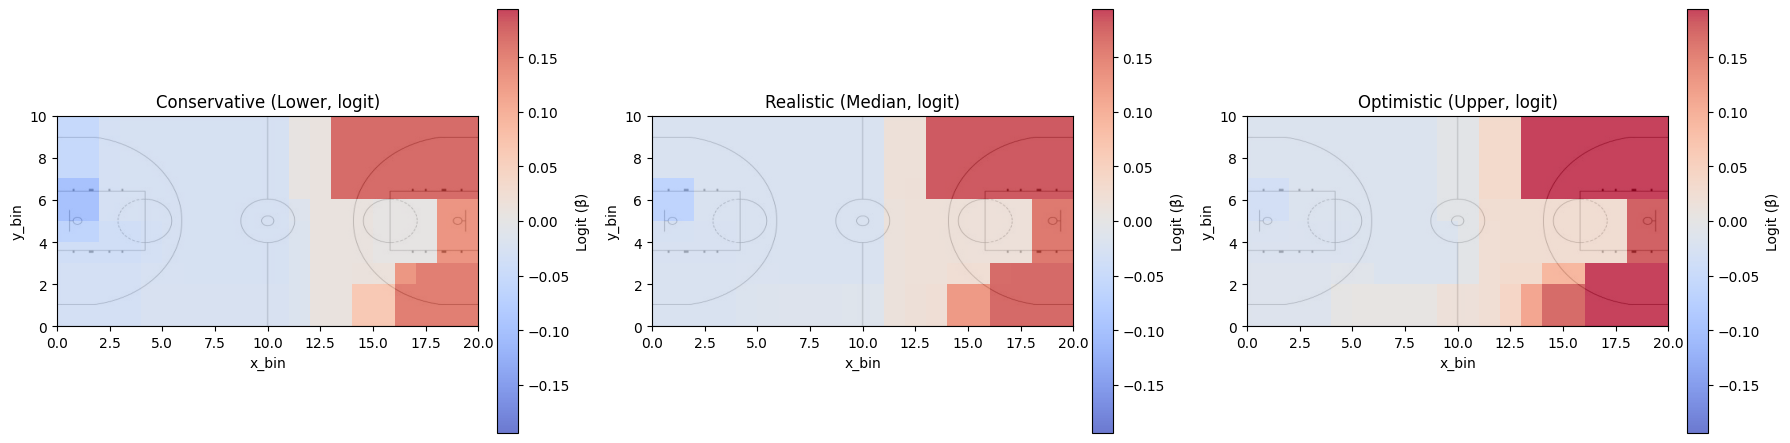

In [ ]:
# Profile 1 (seed 42): reference court pattern.

pipeline_seed = 42
train_set = [21500649, 21500390, 21500188, 21500355, 21500057, 21500009]

# Effects are additive probability adjustments indexed as [x_bin, y_bin].
pipeline_movement_effects = np.zeros((x_bins, y_bins))
pipeline_end_effects = np.zeros((x_bins, y_bins))

pipeline_movement_effects[10:18, 0:3] = .05
pipeline_movement_effects[18:20, 0:3] = .05
pipeline_movement_effects[18:20, 6] = .05
pipeline_movement_effects[10:20, 6:10] = .05
pipeline_movement_effects[18:20, 2:6] = .05
pipeline_movement_effects[10:18, 2:6] = 0
pipeline_movement_effects[10:12, 6:8] = 0
pipeline_movement_effects[10:13, :] = 0
pipeline_movement_effects[18:20, 2:4] = .05

plot_effect_surfaces(pipeline_movement_effects, pipeline_end_effects, title_prefix="Pipeline")

# Sample real trajectories and convert the known spatial profile into one
# scoring probability per sampled possession.
pipeline_results = build_baseline_scoring_pipeline(
    pipeline_input_df,
    train_games=train_set,
    n_possessions=500,
    movement_effects=pipeline_movement_effects,
    end_effects=pipeline_end_effects,
    baseline_probability=0.30,
    random_state=pipeline_seed,
)

pipeline_sampled_movement = pipeline_results["sampled_movement"]
pipeline_sampled_binned_movement = pipeline_results["sampled_binned_movement"]
pipeline_qut_movement = pipeline_results["qut_movement"]
pipeline_visited_posssessions = pipeline_results["visited_posssessions"]
pipeline_baseline_scoring_probabilities = pipeline_results["baseline_scoring_probabilities"]

# Short aliases preserve compatibility with downstream exploratory cells.
visited_posssessions = pipeline_visited_posssessions
baseline_scoring_probabilities = pipeline_baseline_scoring_probabilities
# Draw a reproducible binary outcome from each possession probability.
pipeline_rng = np.random.default_rng(pipeline_seed)
baseline_scoring_probabilities["simulated_out"] = pipeline_rng.binomial(n=1, p=baseline_scoring_probabilities["scoring_probability"])

pipeline_simulated_scoring = baseline_scoring_probabilities[possession_cols + ["simulated_out"]]
pipeline_qut_movement = pipeline_qut_movement.merge(
    pipeline_simulated_scoring,
    on=possession_cols,
    how="left",
)
# Present the simulated label to QUT and discard columns its grid builder does not use.
pipeline_qut_movement["scored"] = pipeline_qut_movement["simulated_out"]
pipeline_qut_movement = pipeline_qut_movement[
    ["possession_number", "x_bin", "y_bin", "scored"]
].copy()

pipeline_n_bootstraps = 100
pipeline_mc_null = 100
pipeline_alpha = 0.05

# Release the previous profile before evaluating the next expensive call.
if "pipeline_qut_results" in globals():
    del pipeline_qut_results
gc.collect()
plt.close("all")

# Recover a TV-regularized spatial profile and quantify lambda uncertainty.
pipeline_qut_results = analyze_tv_logistic_single_game(
    pipeline_qut_movement,
    game_id=None,
    n_bootstraps=pipeline_n_bootstraps,
    n_possessions=10000,
    samples_per_possession=250,
    min_samples_required=100,
    mc_null=pipeline_mc_null,
    alpha=pipeline_alpha,
    court_image_path="court.jpg",
    show_progress=True,
    plot_pointwise_maps=True,
    plot_lambda_distributions=True,
    seed=pipeline_seed,
)

# display(pipeline_qut_movement)

# display(baseline_scoring_probabilities)


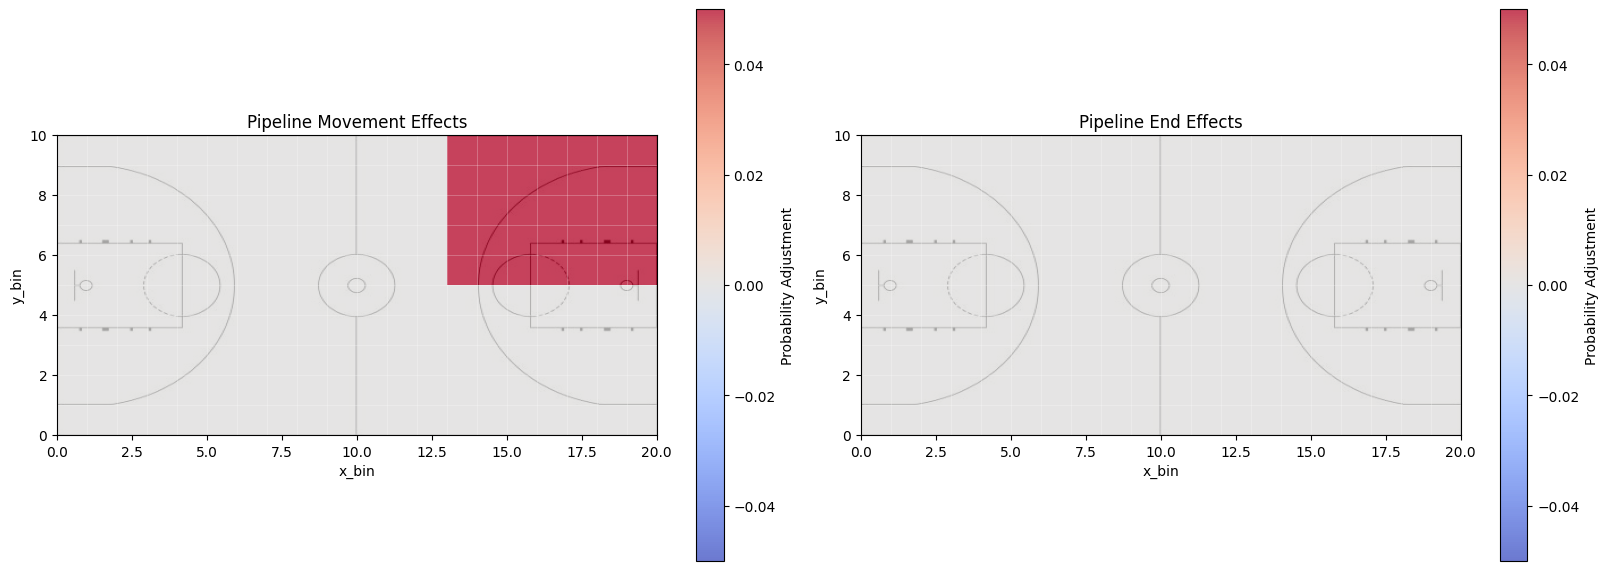


=== Processing single ===


Simulating null responses...
Accepted 100 / 100 simulations
λ_qut (95th percentile null): 80.9076
λ_max (data): 1154.0798


Processing Bootstrap Datasets: 100%|██████████| 100/100 [05:31<00:00,  3.32s/it]

λ_qut (95th percentile null): 80.9076
λ_max (observed): 1154.0798
95% CI for λ_max (bootstrap): [1108.0047, 1261.9983]
Empirical p-value (λ_max > λ_qut): 0.0000


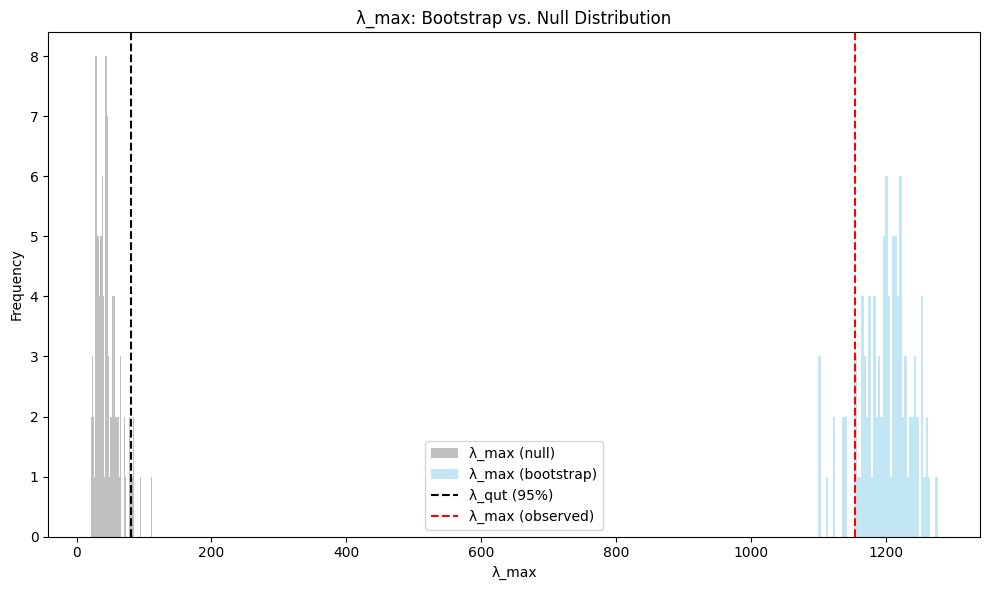

Plotting pointwise percentile maps at lambda = 80.9076


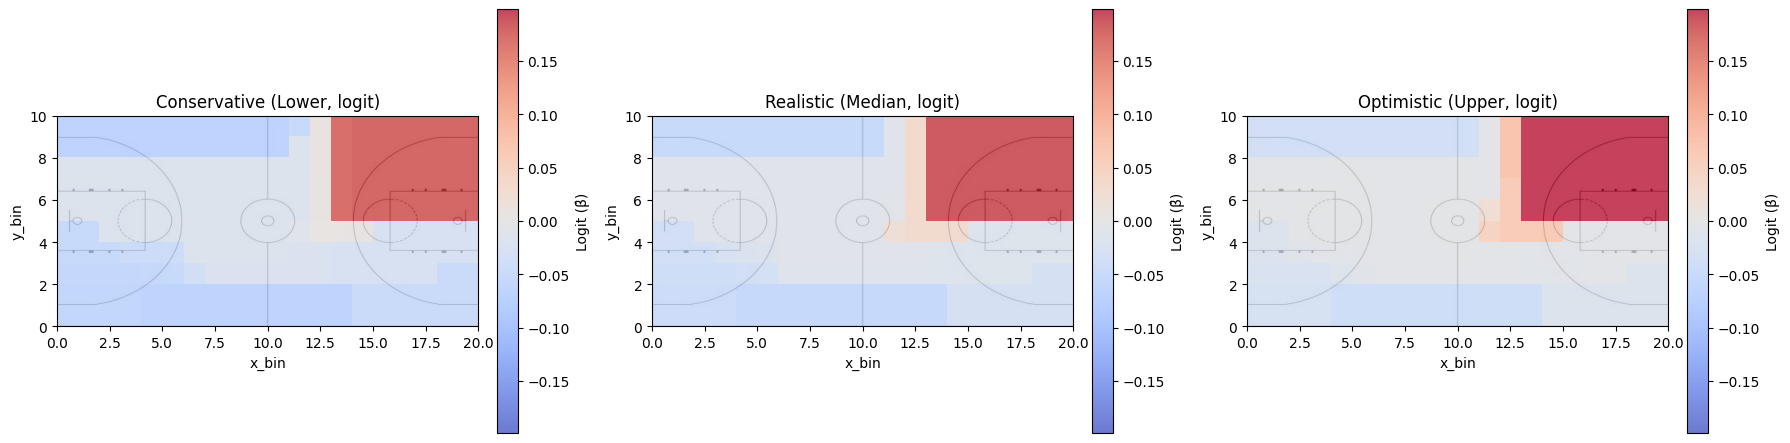

In [13]:
# Profile 2 (seed 43): emphasize the high-y side of the offensive half.
pipeline_seed = 43
train_set = [21500649, 21500390, 21500188, 21500355, 21500057, 21500009]

# Start from a neutral grid, then assign additive probability effects by slice.
pipeline_movement_effects = np.zeros((x_bins, y_bins))
pipeline_end_effects = np.zeros((x_bins, y_bins))

#pipeline_movement_effects[12:20, 6] = .03
pipeline_movement_effects[13:20, 5:10] = .05
#pipeline_movement_effects[10:18, 2:6] = 0
#pipeline_movement_effects[10:12, 6:8] = 0

plot_effect_surfaces(pipeline_movement_effects, pipeline_end_effects, title_prefix="Pipeline")

# Plotting occurs unconditionally; the prompt gates the expensive QUT run.
ask = input("Do you want to run the pipeline with the current settings? (yes/no): ").strip().lower()

if ask == "yes":
    pipeline_results = build_baseline_scoring_pipeline(
        pipeline_input_df,
        train_games=train_set,
        n_possessions=500,
        movement_effects=pipeline_movement_effects,
        end_effects=pipeline_end_effects,
        baseline_probability=0.30,
        random_state=pipeline_seed,
    )

    pipeline_sampled_movement = pipeline_results["sampled_movement"]
    pipeline_sampled_binned_movement = pipeline_results["sampled_binned_movement"]
    pipeline_qut_movement = pipeline_results["qut_movement"]
    pipeline_visited_posssessions = pipeline_results["visited_posssessions"]
    pipeline_baseline_scoring_probabilities = pipeline_results["baseline_scoring_probabilities"]

    visited_posssessions = pipeline_visited_posssessions
    baseline_scoring_probabilities = pipeline_baseline_scoring_probabilities
    pipeline_rng = np.random.default_rng(pipeline_seed)
    baseline_scoring_probabilities["simulated_out"] = pipeline_rng.binomial(n=1, p=baseline_scoring_probabilities["scoring_probability"])

    pipeline_simulated_scoring = baseline_scoring_probabilities[possession_cols + ["simulated_out"]]
    pipeline_qut_movement = pipeline_qut_movement.merge(
        pipeline_simulated_scoring,
        on=possession_cols,
        how="left",
    )
    pipeline_qut_movement["scored"] = pipeline_qut_movement["simulated_out"]
    pipeline_qut_movement = pipeline_qut_movement[
        ["possession_number", "x_bin", "y_bin", "scored"]
    ].copy()

    pipeline_n_bootstraps = 100
    pipeline_mc_null = 100
    pipeline_alpha = 0.05

    # Release the previous profile before evaluating the next expensive call.
    if "pipeline_qut_results" in globals():
        del pipeline_qut_results
    gc.collect()
    plt.close("all")

    pipeline_qut_results = analyze_tv_logistic_single_game(
        pipeline_qut_movement,
        game_id=None,
        n_bootstraps=pipeline_n_bootstraps,
        n_possessions=10000,
        samples_per_possession=250,
        min_samples_required=100,
        mc_null=pipeline_mc_null,
        alpha=pipeline_alpha,
        court_image_path="court.jpg",
        show_progress=True,
        plot_pointwise_maps=True,
        plot_lambda_distributions=True,
        seed=pipeline_seed,
    )

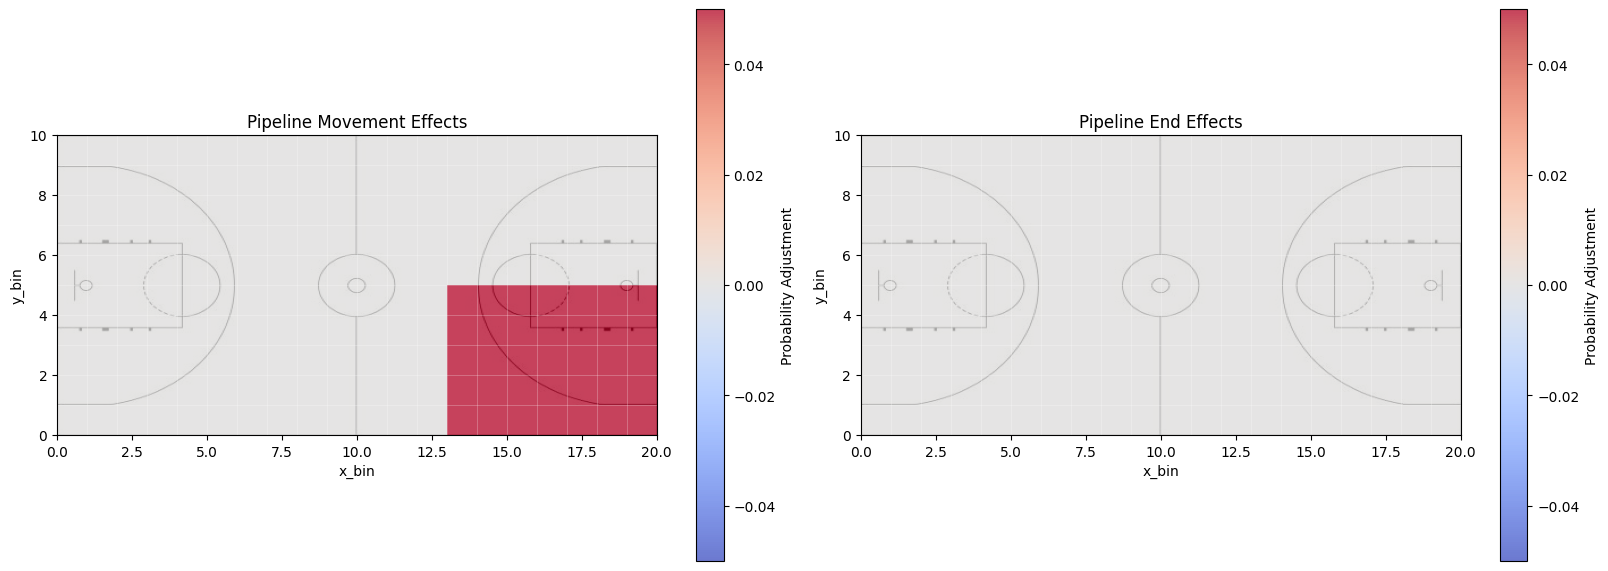


=== Processing single ===


Simulating null responses...
Accepted 100 / 100 simulations
λ_qut (95th percentile null): 83.0711
λ_max (data): 1913.4657


Processing Bootstrap Datasets: 100%|██████████| 100/100 [05:39<00:00,  3.39s/it]

λ_qut (95th percentile null): 83.0711
λ_max (observed): 1913.4657
95% CI for λ_max (bootstrap): [1786.5839, 1916.6244]
Empirical p-value (λ_max > λ_qut): 0.0000


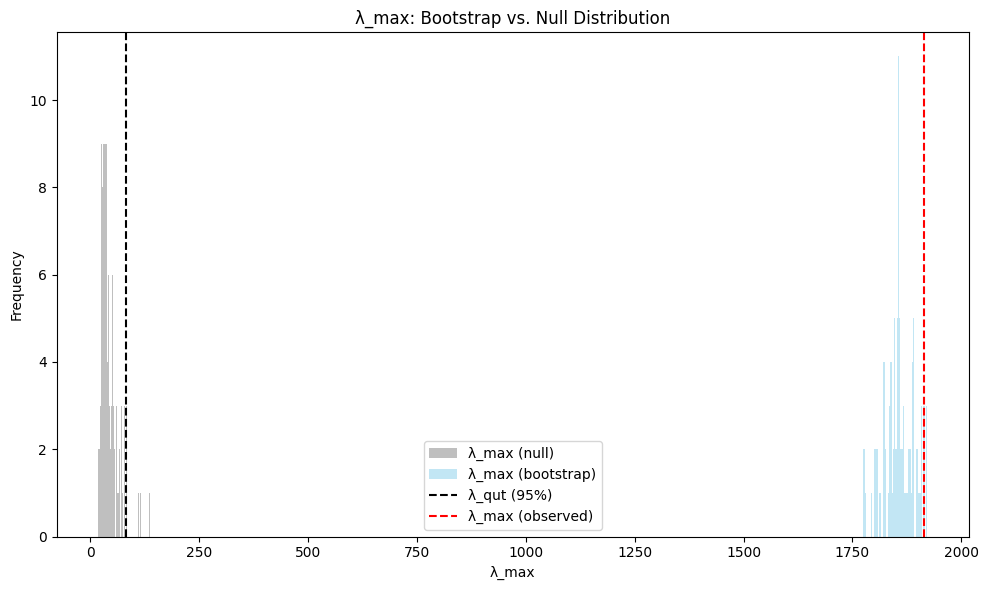

Plotting pointwise percentile maps at lambda = 83.0711


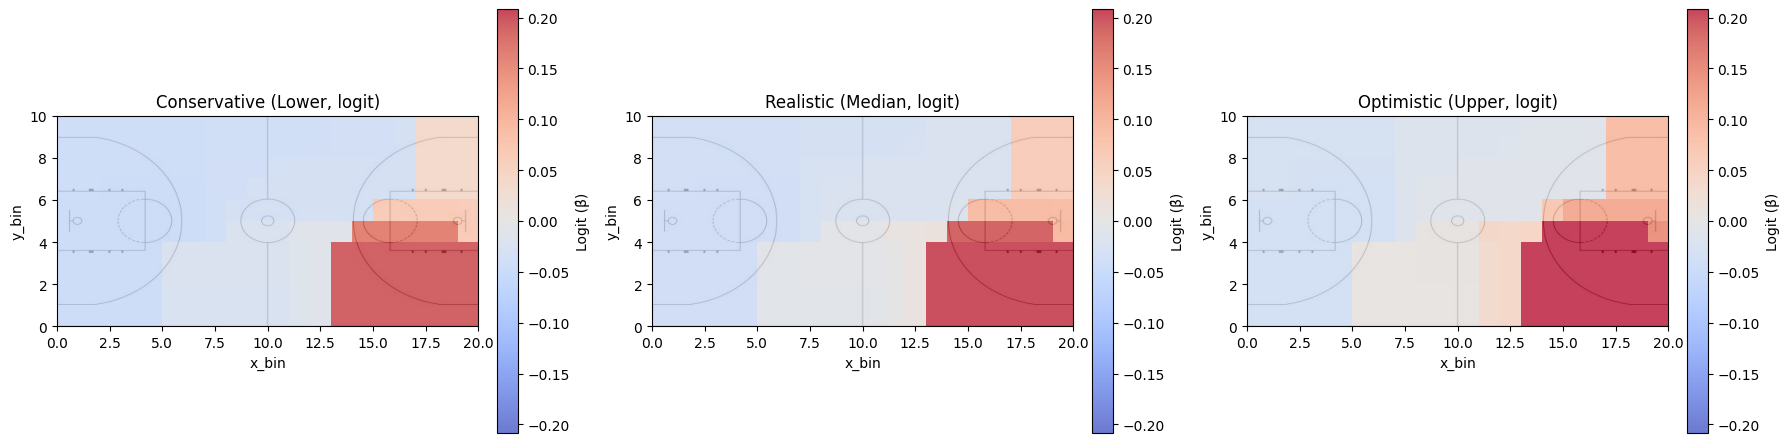

In [16]:
# Profile 3 (seed 44): emphasize the low-y side of the offensive half.
pipeline_seed = 44
train_set = [21500649, 21500390, 21500188, 21500355, 21500057, 21500009]

# Start from a neutral grid, then assign additive probability effects by slice.
pipeline_movement_effects = np.zeros((x_bins, y_bins))
pipeline_end_effects = np.zeros((x_bins, y_bins))

pipeline_movement_effects[13:20, 0:5] = .05
#pipeline_movement_effects[10:18, 2:6] = 0
#pipeline_movement_effects[10:12, 6:8] = 0

plot_effect_surfaces(pipeline_movement_effects, pipeline_end_effects, title_prefix="Pipeline")

# Plotting occurs unconditionally; the prompt gates the expensive QUT run.
ask = input("Do you want to run the pipeline with the current settings? (yes/no): ").strip().lower()

if ask == "yes":
    pipeline_results = build_baseline_scoring_pipeline(
        pipeline_input_df,
        train_games=train_set,
        n_possessions=500,
        movement_effects=pipeline_movement_effects,
        end_effects=pipeline_end_effects,
        baseline_probability=0.30,
        random_state=pipeline_seed,
    )

    pipeline_sampled_movement = pipeline_results["sampled_movement"]
    pipeline_sampled_binned_movement = pipeline_results["sampled_binned_movement"]
    pipeline_qut_movement = pipeline_results["qut_movement"]
    pipeline_visited_posssessions = pipeline_results["visited_posssessions"]
    pipeline_baseline_scoring_probabilities = pipeline_results["baseline_scoring_probabilities"]

    visited_posssessions = pipeline_visited_posssessions
    baseline_scoring_probabilities = pipeline_baseline_scoring_probabilities
    pipeline_rng = np.random.default_rng(pipeline_seed)
    baseline_scoring_probabilities["simulated_out"] = pipeline_rng.binomial(n=1, p=baseline_scoring_probabilities["scoring_probability"])

    pipeline_simulated_scoring = baseline_scoring_probabilities[possession_cols + ["simulated_out"]]
    pipeline_qut_movement = pipeline_qut_movement.merge(
        pipeline_simulated_scoring,
        on=possession_cols,
        how="left",
    )
    pipeline_qut_movement["scored"] = pipeline_qut_movement["simulated_out"]
    pipeline_qut_movement = pipeline_qut_movement[
        ["possession_number", "x_bin", "y_bin", "scored"]
    ].copy()

    pipeline_n_bootstraps = 100
    pipeline_mc_null = 100
    pipeline_alpha = 0.05

    # Release the previous profile before evaluating the next expensive call.
    if "pipeline_qut_results" in globals():
        del pipeline_qut_results
    gc.collect()
    plt.close("all")

    pipeline_qut_results = analyze_tv_logistic_single_game(
        pipeline_qut_movement,
        game_id=None,
        n_bootstraps=pipeline_n_bootstraps,
        n_possessions=10000,
        samples_per_possession=250,
        min_samples_required=100,
        mc_null=pipeline_mc_null,
        alpha=pipeline_alpha,
        court_image_path="court.jpg",
        show_progress=True,
        plot_pointwise_maps=True,
        plot_lambda_distributions=True,
        seed=pipeline_seed,
    )

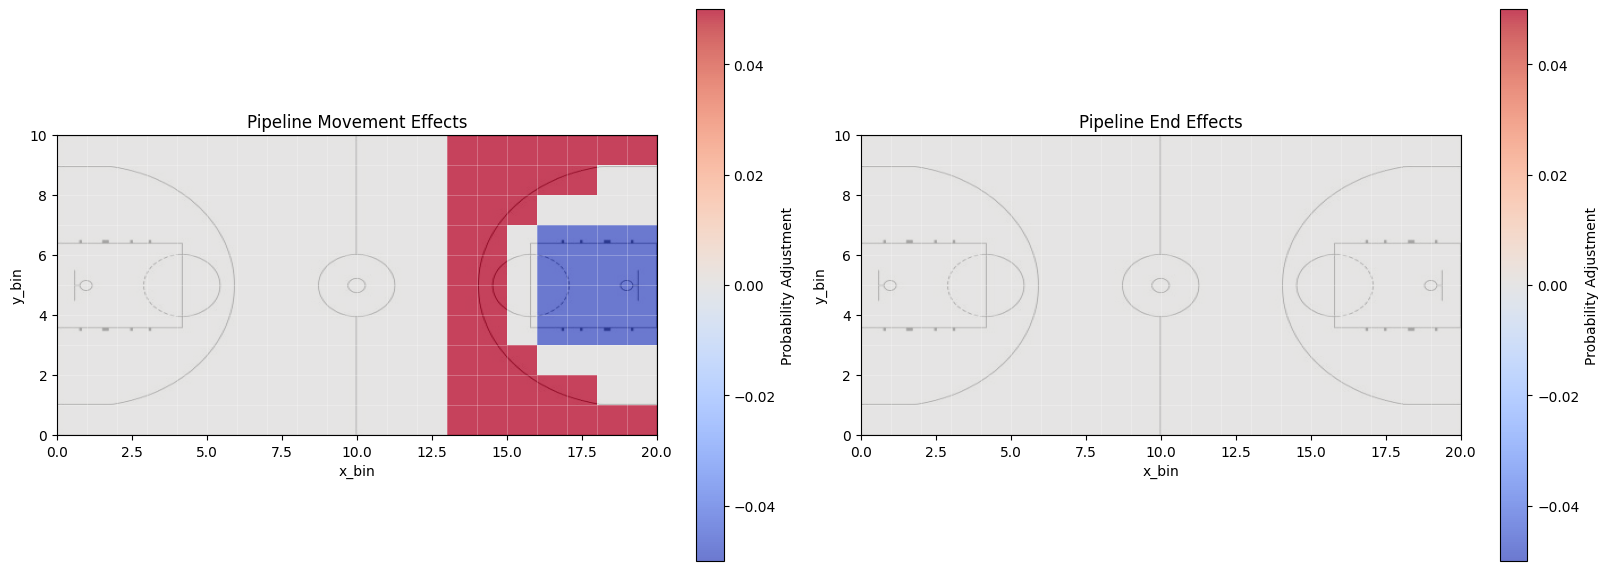


=== Processing single ===


Processing Bootstrap Datasets:   0%|          | 0/100 [00:00<?, ?it/s]

Simulating null responses...
Accepted 100 / 100 simulations
λ_qut (95th percentile null): 79.1725
λ_max (data): 251.2832


Processing Bootstrap Datasets: 100%|██████████| 100/100 [05:32<00:00,  3.33s/it]

λ_qut (95th percentile null): 79.1725
λ_max (observed): 251.2832
95% CI for λ_max (bootstrap): [237.6856, 293.5863]
Empirical p-value (λ_max > λ_qut): 0.0000


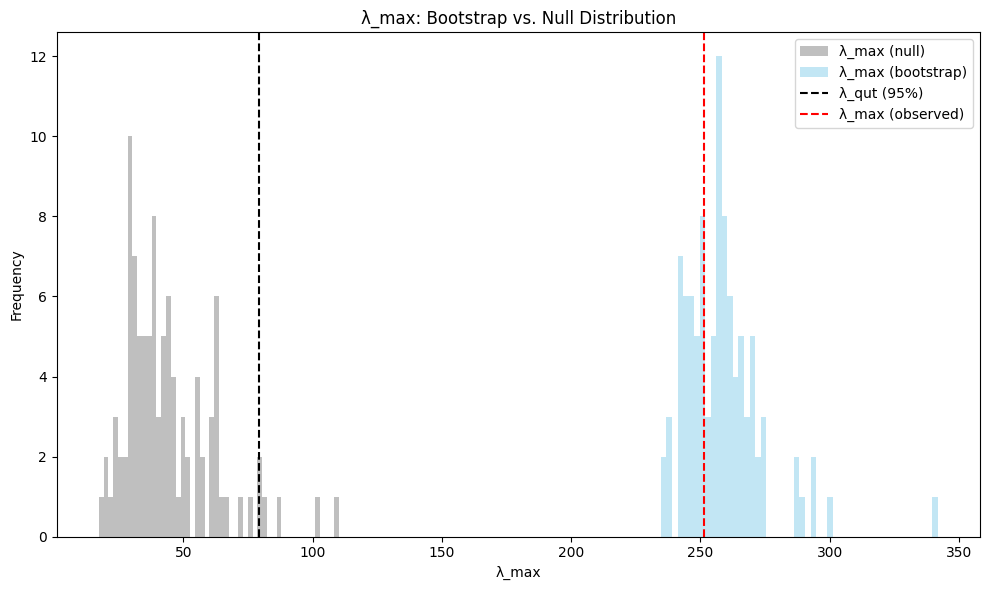

Plotting pointwise percentile maps at lambda = 79.1725


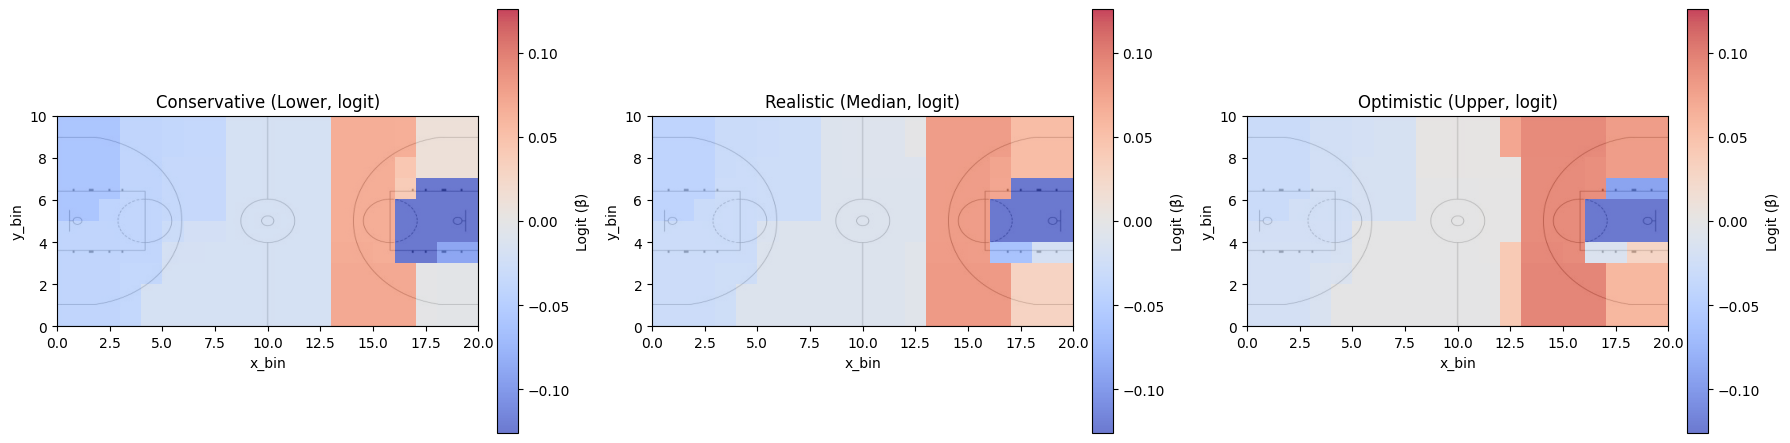

In [11]:
# Profile 4 (seed 45): stepped perimeter-like signal with an interior penalty.
pipeline_seed = 45
train_set = [21500649, 21500390, 21500188, 21500355, 21500057, 21500009]

# Start from a neutral grid, then assign additive probability effects by slice.
pipeline_movement_effects = np.zeros((x_bins, y_bins))
pipeline_end_effects = np.zeros((x_bins, y_bins))

pipeline_movement_effects[15:20, 9] = .05
pipeline_movement_effects[14:18, 8:10] = .05
pipeline_movement_effects[14:16, 7:9] = .05
pipeline_movement_effects[13:15, 3:7] = .05
pipeline_movement_effects[14:20, 0] = .05
pipeline_movement_effects[14:18, 1] = .05
pipeline_movement_effects[14:16, 2] = .05
pipeline_movement_effects[13, 0:10] = .05
pipeline_movement_effects[15:20, 3:7] = -.05
pipeline_movement_effects[18:20, 3:7] = -.05
pipeline_movement_effects[16:18, 3:7] = -.05
pipeline_movement_effects[15, 3:7] = 0
plot_effect_surfaces(pipeline_movement_effects, pipeline_end_effects, title_prefix="Pipeline")

# Plotting occurs unconditionally; the prompt gates the expensive QUT run.
ask = input("Do you want to run the pipeline with the current settings? (yes/no): ").strip().lower()

if ask == "yes":
    pipeline_results = build_baseline_scoring_pipeline(
        pipeline_input_df,
        train_games=train_set,
        n_possessions=500,
        movement_effects=pipeline_movement_effects,
        end_effects=pipeline_end_effects,
        baseline_probability=0.30,
        random_state=pipeline_seed,
    )

    pipeline_sampled_movement = pipeline_results["sampled_movement"]
    pipeline_sampled_binned_movement = pipeline_results["sampled_binned_movement"]
    pipeline_qut_movement = pipeline_results["qut_movement"]
    pipeline_visited_posssessions = pipeline_results["visited_posssessions"]
    pipeline_baseline_scoring_probabilities = pipeline_results["baseline_scoring_probabilities"]

    visited_posssessions = pipeline_visited_posssessions
    baseline_scoring_probabilities = pipeline_baseline_scoring_probabilities
    pipeline_rng = np.random.default_rng(pipeline_seed)
    baseline_scoring_probabilities["simulated_out"] = pipeline_rng.binomial(n=1, p=baseline_scoring_probabilities["scoring_probability"])

    pipeline_simulated_scoring = baseline_scoring_probabilities[possession_cols + ["simulated_out"]]
    pipeline_qut_movement = pipeline_qut_movement.merge(
        pipeline_simulated_scoring,
        on=possession_cols,
        how="left",
    )
    pipeline_qut_movement["scored"] = pipeline_qut_movement["simulated_out"]
    pipeline_qut_movement = pipeline_qut_movement[
        ["possession_number", "x_bin", "y_bin", "scored"]
    ].copy()

    pipeline_n_bootstraps = 100
    pipeline_mc_null = 100
    pipeline_alpha = 0.05

    # Release the previous profile before evaluating the next expensive call.
    if "pipeline_qut_results" in globals():
        del pipeline_qut_results
    gc.collect()
    plt.close("all")

    pipeline_qut_results = analyze_tv_logistic_single_game(
        pipeline_qut_movement,
        game_id=None,
        n_bootstraps=pipeline_n_bootstraps,
        n_possessions=10000,
        samples_per_possession=250,
        min_samples_required=100,
        mc_null=pipeline_mc_null,
        alpha=pipeline_alpha,
        court_image_path="court.jpg",
        show_progress=True,
        plot_pointwise_maps=True,
        plot_lambda_distributions=True,
        seed=pipeline_seed,
    )

## 4. Reading the outputs

After a profile run, the main objects are:

- `pipeline_movement_effects` and `pipeline_end_effects`: the known input signal.
- `pipeline_visited_posssessions`: one row per sampled possession-sector pair.
- `pipeline_baseline_scoring_probabilities`: the component breakdown and final probability for each sampled possession.
- `pipeline_qut_movement`: the four-column QUT input containing the possession identifier, two spatial-bin coordinates, and synthetic `scored` outcome.
- `pipeline_qut_results`: lambda statistics, null/bootstrap distributions, bootstrap coefficient samples, and pointwise percentile maps. Bootstrap tracking tables and mean/standard-deviation maps are not retained.

Useful reconstruction checks include spatial overlap between the nonzero input and recovered regions, sign agreement, effect ranking across regions, and whether pointwise intervals exclude zero where a signal was planted. Because outcomes are random and TV regularization smooths adjacent bins, exact cell-for-cell recovery is not expected.

## Project notes

- Use game `0021500390` for the projection example — done.
- Show the slack-variable mathematics — in progress.
- Four simulations: expected/reference pattern, one-side emphasis, perimeter shooting, and opposite-side emphasis with minimal under-basket emphasis — done.
- Investigate player-measurement covariates.
- Develop quantitative comparisons between the planted simulation profile and the bootstrapped reconstruction.